# Melting Temperature Analysis of FCC Cu

This notebook analyzes the melting temperature of face-centered cubic (fcc) copper (Cu) using molecular dynamics (MD) simulations. The workflow involves:

1. **Loading and organizing MD trajectory data** from solid-liquid coexisting simulations.
2. **Coordination analysis** to distinguish solid and liquid atoms using local order parameters.
3. **Statistical analysis** to determine the fraction of solid and liquid atoms at different temperatures.
4. **Curve fitting** to estimate the melting temperature from the solid-liquid fraction data.

The analysis leverages ASE, pyscal3, and custom utilities for structure handling and visualization.

In [ ]:
# Standard library imports
import os
import glob
from pathlib import Path
from copy import deepcopy
from dataclasses import replace

# Third-party imports
import numpy as np
import pandas as pd
from scipy.signal import fftconvolve
import matplotlib.pyplot as plt
from joblib import Parallel, delayed

from ase.io import read, write, Trajectory
from ase import Atoms, units
from ase.constraints import FixAtoms
from ase.calculators.emt import EMT
from ase.build import stack, bulk
from ase.visualize import view
from ase.optimize import LBFGS

from pyscal3 import System
import json

# Import from refactored md_simulation package
from md_simulation import (
    # Core functionality
    MDSimulationParams,
    run_md,
    # Structure tools
    opt_atoms,
    standardize_atoms,
    build_supercell,
    get_expand_cell_func,
    classify_solid_atoms,
)
from md_simulation.structure.analysis import calculate_bulk_modulus, get_solid_prob
from md_simulation.utils.io import read_yaml

from pfcc_extras.visualize import view_ngl
from pfcc_extras.structure.connectivity import get_neighbors

# Model version and calculation mode for calculator (if using ML/DFT)
MODEL_VERSION = "v7.0.0"
CALC_MODE = 'PBE_PLUS_D3'

def get_calculator(model_version=MODEL_VERSION, calc_mode=CALC_MODE):
    """
    Returns an ASE calculator for the given model version and calculation mode.
    Currently returns EMT as a placeholder.
    """
    calculator = EMT()
    # Uncomment and adjust below for ML/DFT calculator integration
    # if isinstance(calc_mode, str):
    #     calc_mode = getattr(EstimatorCalcMode, calc_mode)
    # estimator = Estimator(model_version=model_version, calc_mode=calc_mode)
    # calculator = ASECalculator(estimator)
    return calculator

## Set Up Input and Output Directories
Define paths for input and output data directories. This ensures all file operations are relative to the notebook location.

In [2]:
cwd = Path().resolve()
inputdir = cwd / "input"
outputdir = cwd / "output"


## Analyze Solid-Liquid Coexistence Trajectories
Load the MD trajectories from solid-liquid coexistence simulations. For each trajectory, compute the solid probability using local order analysis, and classify each as solid or liquid. Summarize the number of solid and liquid samples at each temperature and visualize the results.

(4, 5)


,num_solids,num_liquid,temperature
4,4,0,838.265838
0,4,0,1026.099360
1,2,2,1204.070123
2,0,4,1383.381123
3,0,4,1569.687706


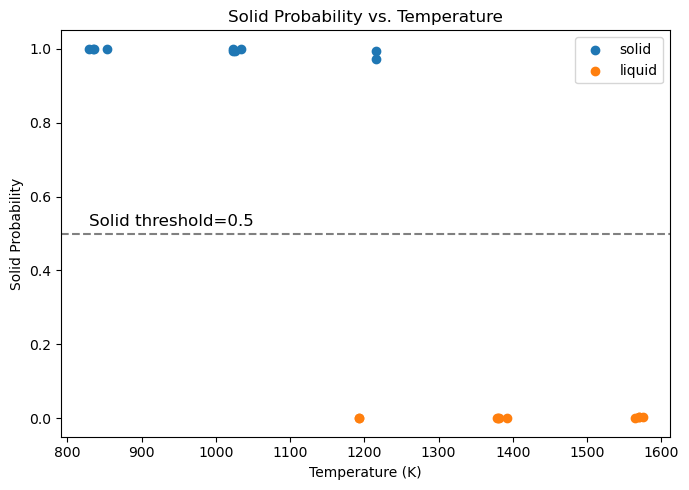

In [7]:
# Set the threshold for classifying solid atoms
solid_threshold = 0.5

# Load the equilibrium structure for the coexisting phase (solid + liquid)
coex_equilib = read(outputdir / 'coex_equilib.json')

# Find and organize trajectory files for each temperature and iteration
trajfiles = sorted(outputdir.glob('coex_it*.traj'))
trajfiles = np.array(trajfiles).reshape(-1, 5)  # (num_iterations, num_temperatures)
print(trajfiles.shape) 
# Load all trajectories into memory (list of list of Trajectory objects)
trajectories = [[Trajectory(traj_path) for traj_path in traj_group] for traj_group in trajfiles]

# Compute solid probabilities for the last frame of each trajectory
solid_probs = np.array([[np.mean(get_solid_prob(traj[-1])) for traj in traj_group] for traj_group in trajectories])

# Compute mean temperature and volume for each trajectory group
temperatures_traj = np.array([[np.mean([frame.get_temperature() for frame in traj]) for traj in traj_group] for traj_group in trajectories])
volumes_traj = np.array([[np.mean([frame.get_volume() for frame in traj]) for traj in traj_group] for traj_group in trajectories])

# Classify each trajectory as solid or liquid based on the threshold
mask_solid = solid_probs > solid_threshold
num_solid = np.count_nonzero(mask_solid, axis=0)
num_liquid = solid_probs.shape[0] - num_solid

# Compute average temperature for each temperature set
temperatures = temperatures_traj.mean(axis=0)

# Create a DataFrame summarizing the number of solid and liquid samples at each temperature
df = pd.DataFrame({
    'num_solids': num_solid,
    'num_liquid': num_liquid,
    'temperature': temperatures
}).sort_values('temperature')
display(df)

# Plot solid probability vs. temperature for all samples
plt.figure(figsize=(7, 5))
plt.scatter(temperatures_traj[mask_solid], solid_probs[mask_solid], label='solid')
plt.scatter(temperatures_traj[~mask_solid], solid_probs[~mask_solid], label='liquid')
plt.axhline(solid_threshold, color='gray', linestyle='dashed')
plt.text(temperatures_traj.min(), solid_threshold + 0.02, f'Solid threshold={solid_threshold}', fontsize=12)
plt.legend()
plt.xlabel('Temperature (K)')
plt.ylabel('Solid Probability')
plt.title('Solid Probability vs. Temperature')
plt.tight_layout()

## Estimate Melting Temperature by Sigmoid Fitting
Fit a sigmoid function to the fraction of liquid atoms as a function of temperature. The inflection point of the sigmoid corresponds to the estimated melting temperature. The result is visualized and the melting temperature is annotated on the plot.

Curve fit for Cu:[8.89514504e-02 1.20407012e+03]


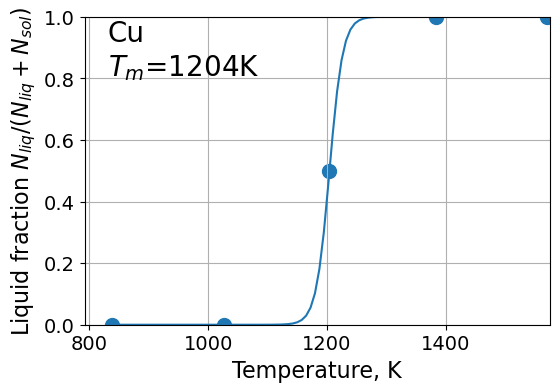

In [8]:
from scipy.optimize import curve_fit

def sigmoid(t, c, tm):
    """Sigmoid function for fitting the liquid fraction curve.
    c: steepness, tm: melting temperature"""
    return 1/(1+np.exp(-c*(t-tm)))

# Get chemical formula for labeling
formula = coex_equilib.get_chemical_formula(empirical=True)

# Prepare figure for plotting liquid fraction vs. temperature
fig, ax = plt.subplots(figsize=(6,4))

# Set temperature range for fitting and plotting
tmin = temperatures_traj.min()
tmax = temperatures_traj.max()
xlim = (tmin - 0.05*(tmax-tmin), tmax)

# Calculate liquid fraction at each temperature
frac_liquid = num_liquid/(num_liquid + num_solid)

# Fit the sigmoid function to the liquid fraction data to estimate melting temperature
ax.scatter(temperatures, frac_liquid, s=100)
popt, pconv = curve_fit(sigmoid, temperatures, frac_liquid, [0.05, (tmax+tmin)*0.5], bounds=[[1e-3, 0.1], xlim])
print(f'Curve fit for {formula}:{popt}')

# Plot the fitted sigmoid curve
ax.set_xlabel('Temperature, K', fontsize=16)
ax.set_ylabel('Liquid fraction $N_{liq} / (N_{liq}+N_{sol})$', fontsize=16)
ax.grid()
ax.tick_params(labelsize=14)
t = np.linspace(tmin, tmax, 101)
ax.plot(t, sigmoid(t, *popt))

# Annotate the plot with the estimated melting temperature
ax.text(xlim[0] + (xlim[1]-xlim[0])*0.05, 0.81, f'{formula}\n$T_{{m}}$={popt[1]:.0f}K', fontsize=20)

ax.set_xlim(xlim)
ax.set_ylim(0,1)
plt.savefig(f'melting_temperature_metals_{formula}.png')

## Visualize Trajectory Structure
Display a selected MD trajectory using an interactive 3D viewer to inspect the atomic configuration at a given temperature and iteration.

In [9]:
# Visualize a selected trajectory using NGL viewer (interactive 3D visualization)
view_ngl(trajectories[1][1], replace_structure=True)